# Análisis de Sensibilidad: KDE vs gridsize

Objetivo: encontrar el **primer** valor de `gridsize` (entre 10,000 y 100,000)
donde el delta máximo respecto a la referencia (gridsize=100,000) sea ≤ 0.001.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy.stats import gaussian_kde

In [2]:
# ── Configuración GPU ─────────────────────────────────────────────────────────
USE_GPU = True   # Cambia a False para forzar el uso de CPU

_gpu_ok = False
if USE_GPU:
    try:
        import cupy as cp
        n_dev = cp.cuda.runtime.getDeviceCount()
        if n_dev == 0:
            raise RuntimeError("No se detectaron GPUs CUDA.")
        free_mem, total_mem = cp.cuda.Device(0).mem_info
        print(f"GPU disponible: {n_dev} dispositivo(s)")
        print(f"  Memoria: {free_mem/1e9:.1f} GB libres / {total_mem/1e9:.1f} GB totales")
        _gpu_ok = True
    except ImportError:
        print("CuPy no encontrado. Instalalo con:  pip install cupy-cuda12x  (o cupy-cuda11x segun tu version de CUDA)")
        print("Usando CPU.")
    except Exception as e:
        print(f"GPU no disponible ({e}). Usando CPU.")
else:
    print("Modo CPU seleccionado (USE_GPU=False).")

print(f"\nBackend activo: {'GPU (CuPy)' if _gpu_ok else 'CPU (NumPy / SciPy)'}")

GPU disponible: 1 dispositivo(s)
  Memoria: 7.4 GB libres / 8.6 GB totales

Backend activo: GPU (CuPy)


## 1. Carga de datos

In [3]:
FILE_PATH = r"C:\Users\manue\OneDrive\Escritorio\Clustering_Microbiota\Datos\otu_data_converted.csv"

path = Path(FILE_PATH)
if not path.exists():
    raise FileNotFoundError(f"No existe el archivo: {path}")

df = pd.read_csv(path, delimiter=",")
print(f"Shape del DataFrame: {df.shape}")
df.head(3)

Shape del DataFrame: (441, 4739)


,ID,Otu00001,Otu00002,Otu00003,Otu00004,Otu00005,Otu00006,Otu00007,Otu00008,Otu00009,...,Otu04757,Otu04758,Otu04759,Otu04760,Otu04761,Otu04762,Otu04763,Otu04764,Otu04765,Otu04766
0,MI_001_H,354,817,50,31,448,547,727,353,2,...,0,0,0,0,0,0,0,0,0,0
1,MI_002_H,168,9,131,3005,68,10187,570,2006,104,...,0,0,0,0,0,0,0,0,0,0
2,MI_003_H,19,174,6211,79,1063,0,6077,1852,1471,...,0,0,0,0,0,0,0,0,0,0


## 2. Preparación de datos (misma lógica que el bloque KDE original)

In [ ]:
# Parámetros KDE (iguales al bloque original)
BW_METHOD  = "scott"
UMBRAL     = 0.001   # delta máximo aceptable
GRIDSIZE_REF  = 100_000
GRIDSIZE_MIN  = 1_0000
GRIDSIZE_STEP = 1_000

# Preparar datos numéricos positivos
df_num = df.select_dtypes(include=[np.number])
if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]
data_kde = valores[valores > 0]

if len(data_kde) == 0:
    raise ValueError("No hay datos positivos para KDE.")

print(f"N positivos: {len(data_kde):,}")
print(f"min = {data_kde.min():.4g}   max = {data_kde.max():.4g}")

N positivos: 105,420
min = 1   max = 6.071e+04


## 3. Análisis de sensibilidad

Para cada `gridsize` N:
1. Evalúa la KDE en N puntos log-espaciados en el rango de datos.
2. Interpola esos N valores a la malla de referencia (100,000 puntos).
3. Calcula el delta = `max |y_N_interpolado − y_ref|`.

In [5]:
import time
from tqdm.notebook import tqdm

# Construir el objeto KDE (único para todos los gridsizes)
kde = gaussian_kde(data_kde, bw_method=BW_METHOD)
sigma = float(np.sqrt(kde.covariance[0, 0]))   # sigma del kernel gaussiano

# ── Definir función de evaluación (GPU o CPU) ─────────────────────────────────
if _gpu_ok:
    # Pre-cargar datos en GPU una sola vez
    _data_gpu = cp.asarray(data_kde, dtype=cp.float64)
    _n_data   = len(_data_gpu)
    _norm     = float(1.0 / (_n_data * sigma * np.sqrt(2.0 * np.pi)))

    # Chunk size automático: usar ~25 % de la memoria libre
    _free_mem, _ = cp.cuda.Device(0).mem_info
    _chunk = max(100, min(10_000, int(_free_mem * 0.25 / (_n_data * 8))))
    print(f"GPU chunk size: {_chunk:,} puntos de evaluacion por lote")

    def _eval_kde(x_eval):
        """Evalúa la KDE en x_eval sobre GPU (CuPy)."""
        x_gpu = cp.asarray(x_eval, dtype=cp.float64)
        y_out = cp.empty(len(x_gpu), dtype=cp.float64)
        for i in range(0, len(x_gpu), _chunk):
            xc   = x_gpu[i : i + _chunk]                      # (chunk,)
            diff = xc[:, None] - _data_gpu[None, :]            # (chunk, n_data)
            y_out[i : i + _chunk] = _norm * cp.sum(
                cp.exp(-0.5 * (diff / sigma) ** 2), axis=1
            )
        return cp.asnumpy(y_out)
else:
    def _eval_kde(x_eval):
        """Evalúa la KDE en x_eval sobre CPU (scipy)."""
        return kde(x_eval)

# ── Malla de referencia ───────────────────────────────────────────────────────
x_ref = np.logspace(
    np.log10(data_kde.min()),
    np.log10(data_kde.max()),
    GRIDSIZE_REF
)
print("Calculando KDE de referencia...")
t0 = time.perf_counter()
y_ref = _eval_kde(x_ref)
print(f"  Referencia lista en {time.perf_counter()-t0:.2f}s")

# ── Bucle de sensibilidad ─────────────────────────────────────────────────────
gridsizes = np.arange(GRIDSIZE_MIN, GRIDSIZE_REF, GRIDSIZE_STEP)
deltas    = []

t0 = time.perf_counter()

for n in tqdm(gridsizes, desc="Sensibilidad gridsize", unit="grid",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):
    x_n      = np.logspace(np.log10(data_kde.min()), np.log10(data_kde.max()), n)
    y_n      = _eval_kde(x_n)
    y_interp = np.interp(x_ref, x_n, y_n)
    deltas.append(float(np.max(np.abs(y_interp - y_ref))))

elapsed = time.perf_counter() - t0
print(f"Completado en {elapsed:.2f}s  ({elapsed / len(gridsizes) * 1000:.1f} ms/gridsize)")

deltas = np.array(deltas)

# ── Resultado ─────────────────────────────────────────────────────────────────
mask_ok = deltas <= UMBRAL
if mask_ok.any():
    idx_opt      = int(np.argmax(mask_ok))
    gridsize_opt = int(gridsizes[idx_opt])
    delta_opt    = float(deltas[idx_opt])
    print(f"\nPrimer gridsize con delta <= {UMBRAL}: {gridsize_opt:,}  (delta = {delta_opt:.6f})")
else:
    gridsize_opt = None
    print(f"\nNingun gridsize en el rango alcanza delta <= {UMBRAL}.")
    print(f"  Delta minimo: {deltas.min():.6f} en gridsize={int(gridsizes[np.argmin(deltas)]):,}")


GPU chunk size: 2,205 puntos de evaluacion por lote
Calculando KDE de referencia...
  Referencia lista en 13.28s


Sensibilidad gridsize:   0%|          | 0/99 [00:00<?, ?grid/s]

Completado en 683.63s  (6905.3 ms/gridsize)

Primer gridsize con delta <= 0.001: 1,000  (delta = 0.000000)


## 4. Visualización

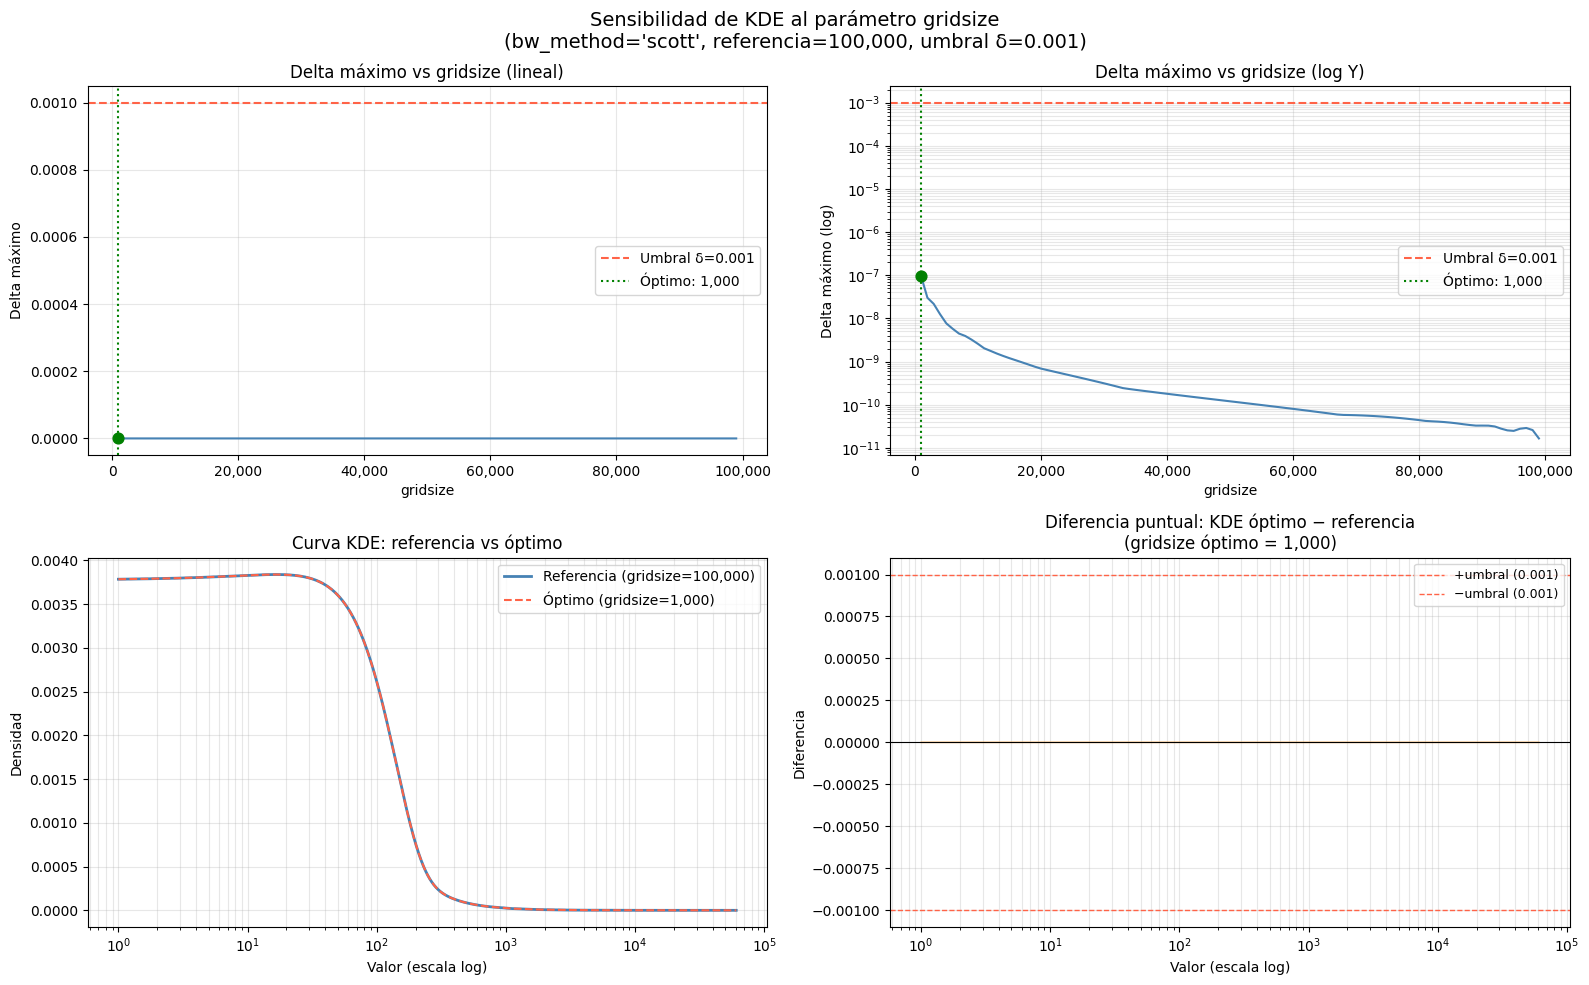

Figura guardada como 'kde_gridsize_sensitivity.png'


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sensibilidad de KDE al parámetro gridsize\n"
             f"(bw_method='{BW_METHOD}', referencia={GRIDSIZE_REF:,}, umbral δ={UMBRAL})",
             fontsize=14)

# ── Gráfico 1: Delta vs gridsize (escala lineal) ─────────────────────────────
ax = axes[0, 0]
ax.plot(gridsizes, deltas, linewidth=1.5, color="steelblue")
ax.axhline(UMBRAL, color="tomato", linestyle="--", linewidth=1.5, label=f"Umbral δ={UMBRAL}")
if gridsize_opt is not None:
    ax.axvline(gridsize_opt, color="green", linestyle=":", linewidth=1.5,
               label=f"Óptimo: {gridsize_opt:,}")
    ax.scatter([gridsize_opt], [delta_opt], color="green", zorder=5, s=60)
ax.set_xlabel("gridsize")
ax.set_ylabel("Delta máximo")
ax.set_title("Delta máximo vs gridsize (lineal)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Gráfico 2: Delta vs gridsize (escala log en Y) ───────────────────────────
ax = axes[0, 1]
ax.semilogy(gridsizes, deltas, linewidth=1.5, color="steelblue")
ax.axhline(UMBRAL, color="tomato", linestyle="--", linewidth=1.5, label=f"Umbral δ={UMBRAL}")
if gridsize_opt is not None:
    ax.axvline(gridsize_opt, color="green", linestyle=":", linewidth=1.5,
               label=f"Óptimo: {gridsize_opt:,}")
    ax.scatter([gridsize_opt], [delta_opt], color="green", zorder=5, s=60)
ax.set_xlabel("gridsize")
ax.set_ylabel("Delta máximo (log)")
ax.set_title("Delta máximo vs gridsize (log Y)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Gráfico 3: KDE referencia vs KDE óptima ──────────────────────────────────
ax = axes[1, 0]
ax.plot(x_ref, y_ref, color="steelblue", linewidth=2, label=f"Referencia (gridsize={GRIDSIZE_REF:,})", zorder=3)
if gridsize_opt is not None:
    x_opt = np.logspace(np.log10(data_kde.min()), np.log10(data_kde.max()), gridsize_opt)
    y_opt = kde(x_opt)
    ax.plot(x_opt, y_opt, color="tomato", linewidth=1.5, linestyle="--",
            label=f"Óptimo (gridsize={gridsize_opt:,})", zorder=4)
ax.set_xscale("log")
ax.set_xlabel("Valor (escala log)")
ax.set_ylabel("Densidad")
ax.set_title("Curva KDE: referencia vs óptimo")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

# ── Gráfico 4: Diferencia puntual (referencia − óptimo) en la malla de ref ──
ax = axes[1, 1]
if gridsize_opt is not None:
    y_opt_interp = np.interp(x_ref, x_opt, y_opt)
    diff = y_opt_interp - y_ref
    ax.plot(x_ref, diff, color="darkorange", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axhline( UMBRAL, color="tomato", linestyle="--", linewidth=1, label=f"+umbral ({UMBRAL})")
    ax.axhline(-UMBRAL, color="tomato", linestyle="--", linewidth=1, label=f"−umbral ({UMBRAL})")
    ax.set_xscale("log")
    ax.set_xlabel("Valor (escala log)")
    ax.set_ylabel("Diferencia")
    ax.set_title(f"Diferencia puntual: KDE óptimo − referencia\n(gridsize óptimo = {gridsize_opt:,})")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which="both")
else:
    ax.text(0.5, 0.5, "No se encontró gridsize óptimo",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)
    ax.set_title("Diferencia puntual")

plt.tight_layout()
plt.savefig("kde_gridsize_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada como 'kde_gridsize_sensitivity.png'")

## 5. Resumen

In [7]:
print("="*55)
print("RESUMEN DEL ANÁLISIS DE SENSIBILIDAD KDE")
print("="*55)
print(f"  bw_method        : {BW_METHOD}")
print(f"  Datos (N pos)    : {len(data_kde):,}")
print(f"  Referencia       : gridsize = {GRIDSIZE_REF:,}")
print(f"  Rango explorado  : {GRIDSIZE_MIN:,} → {int(gridsizes[-1]):,} (paso {GRIDSIZE_STEP:,})")
print(f"  Umbral δ         : {UMBRAL}")
print("-"*55)
print(f"  Delta máximo en gridsize={GRIDSIZE_MIN:,}  : {deltas[0]:.6f}")
print(f"  Delta mínimo encontrado  : {deltas.min():.6f} (gridsize={int(gridsizes[np.argmin(deltas)]):,})")
if gridsize_opt is not None:
    print(f"   Primer gridsize con δ≤{UMBRAL}: {gridsize_opt:,}  (delta={delta_opt:.6f})")
    print(f"  Ahorro vs referencia: {GRIDSIZE_REF - gridsize_opt:,} puntos menos")
    print(f"  ({100*(GRIDSIZE_REF-gridsize_opt)/GRIDSIZE_REF:.1f}% menos que la referencia)")
else:
    print(f"  ⚠ Ningún gridsize en el rango alcanzó δ ≤ {UMBRAL}.")
print("="*55)

RESUMEN DEL ANÁLISIS DE SENSIBILIDAD KDE
  bw_method        : scott
  Datos (N pos)    : 105,420
  Referencia       : gridsize = 100,000
  Rango explorado  : 1,000 → 99,000 (paso 1,000)
  Umbral δ         : 0.001
-------------------------------------------------------
  Delta máximo en gridsize=1,000  : 0.000000
  Delta mínimo encontrado  : 0.000000 (gridsize=99,000)
   Primer gridsize con δ≤0.001: 1,000  (delta=0.000000)
  Ahorro vs referencia: 99,000 puntos menos
  (99.0% menos que la referencia)
